**Виконав Гуленко Назар, студент групи ІДС-501**

## Завдання 1. Поліноміальна регресія: залежність mpg від horsepower

In [1]:
# Імпорт необхідних бібліотек для обробки даних, моделювання та візуалізації
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import resample

**Завантаження набору даних Auto MPG**

In [2]:
data = pd.read_csv(r"C:\Users\User\Documents\Machine_Learning\auto.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 24.6 KB


**1.Побудуйте послідовність регресійних моделей, що описують залежність mpg від horsepower:**

**Лінійна регресія (ступінь 1) та поліноміальна регресія ступенів 2-6**

In [4]:
# Визначення ознаки (horsepower) та цільової змінної (mpg)
X = data[['horsepower']]
y = data['mpg']

In [5]:
# Визначення діапазону ступенів полінома (від 1 до 6)
degrees = range(1,7)
models = {}

# Списки для збереження значень помилок
train_errors = []
cv_errors = []

# Цикл для побудови та оцінки моделей різних ступенів складності
for deg in degrees:
    # Створення Pipeline: перетворення ознак у поліноміальні + лінійна регресія
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    # Навчання моделі на повному наборі даних
    model.fit(X, y)
    models[deg] = model

    # Отримання прогнозів та розрахунок MSE на навчальній вибірці
    y_pred = model.predict(X)
    mse_train = mean_squared_error(y, y_pred)
    train_errors.append(mse_train)

    # Оцінка здатності до узагальнення за допомогою 5-кратної крос-валідації
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=5
    )

    # Розрахунок середньої помилки крос-валідації (зміна знака)
    mse_cv = -scores.mean()
    cv_errors.append(mse_cv)

**Фіксація помилки у табличному вигляді**

In [6]:
# Формування підсумкової таблиці з помилками для кожного ступеня
results = pd.DataFrame({
    "Degree": list(degrees),
    "Train_MSE": train_errors,
    "CV_MSE": cv_errors
})

# Виведення результатів порівняння
print(results)

   Degree  Train_MSE     CV_MSE
0       1  23.943663  31.447014
1       2  18.984769  24.347159
2       3  18.944990  24.346078
3       4  18.876333  24.355390
4       5  18.426969  23.573284
5       6  18.611527  23.928287


Бачимо, що наймеше відхилення досягається при ступені 5

**Побудова графіків**

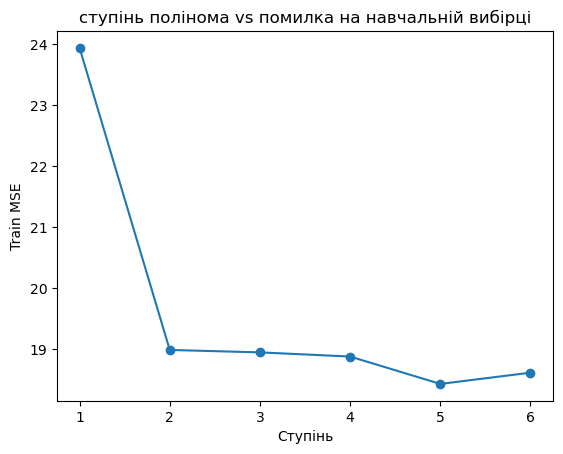

In [7]:
# Побудова графіка залежності помилки на навчальній вибірці від ступеня полінома
plt.figure()

plt.plot(degrees, train_errors, marker='o', label='Train MSE')

plt.xlabel("Ступінь")
plt.ylabel("Train MSE")
plt.title("ступінь полінома vs помилка на навчальній вибірці")

plt.show()

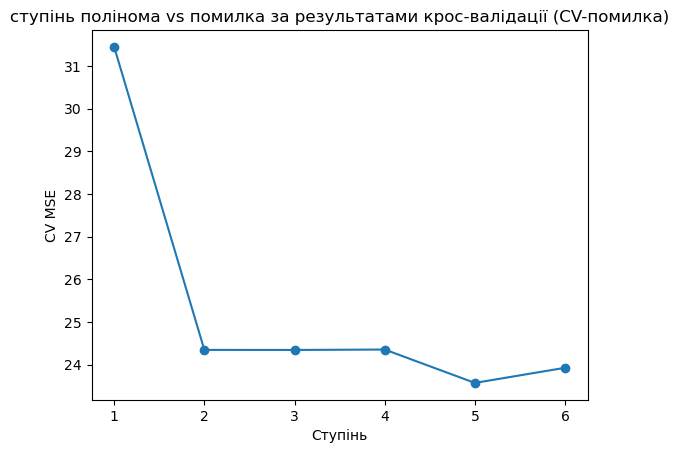

In [8]:
#Побудова графіка залежності ступінь полінома vs помилка за результатами крос-валідації (CV-помилка)
plt.figure()

plt.plot(degrees, cv_errors, marker='o')

plt.xlabel("Ступінь")
plt.ylabel("CV MSE")
plt.title("ступінь полінома vs помилка за результатами крос-валідації (CV-помилка)")

plt.show()

Проведений експеримент демонструє класичну поведінку помилок при зміні складності моделі. Поліном першого ступеня  демонструє найвищий рівень MSE на обох вибірках, що свідчить про недонавчання — модель занадто проста для опису нелінійної залежності в даних.

Зі збільшенням ступеня до другого спостерігається різке зниження помилки, після чого графік стабілізується. Оптимальним вибором є поліном 2-го або 3-го ступеня, оскільки подальше ускладнення моделі не дає суттєвого покращення на тесті, але підвищує ризик перенавчання (overfitting), де модель почне підлаштовуватися під випадковий шум у навчальних даних.

**Графічна ілюстрація**

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\User\anacon

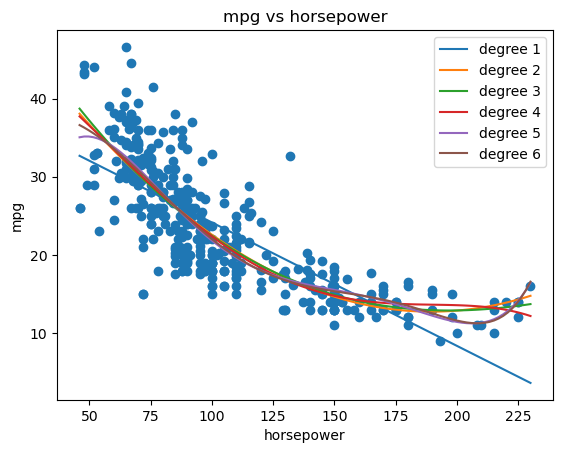

In [9]:
plt.figure()
plt.scatter(X, y)
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
for deg, model in models.items():

    y_pred = model.predict(x_range)

    plt.plot(x_range, y_pred, label=f"degree {deg}")

plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.title("mpg vs horsepower")

plt.legend()
plt.show()

ізуальний аналіз розподілу даних свідчить про наявність чітко вираженого нелінійного характеру залежності між потужністю двигуна (horsepower) та витратою палива (mpg).

При порівнянні моделей різного ступеня складності спостерігаються наступні ефекти:

-Лінійна модель (ступінь 1) демонструє ознаки недонавчання (underfitting), не враховуючи параболічний тренд даних.

-Квадратична модель (ступінь 2) забезпечує найбільш оптимальний баланс, описуючи основну закономірність без надмірної деталізації шуму.

-Модель високого порядку (ступінь 5) починає надмірно підлаштовуватися під локальні флуктуації, що вказує на ризик перенавчання (overfitting) та можливе зростання дисперсії прогнозу на нових даних.

## Завдання 2. Регуляризація як контроль компромісу між зміщенням і дисперсією

In [10]:
df = pd.read_csv(r"C:\Users\User\Documents\Machine_Learning\hitters.csv")
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

Заповнимо пропущені значення цільової змінної Salary медіанним значенням

In [12]:
median_salary = df['Salary'].median()
df['Salary'] = df['Salary'].fillna(median_salary)
salary_nans = df['Salary'].isna().sum()
print(f"\nПропусків у Salary: {salary_nans}")


Пропусків у Salary: 0


**1.Побудуйте три типи моделей:**

In [13]:
y = df['Salary']
X = df.drop(columns=['Salary'])

# категоріальні змінні
X = pd.get_dummies(X, drop_first=True)

# Задаємо широкий діапазон значень параметра регуляризації λ
alphas = np.logspace(-3, 4, 200)

# Налаштування крос-валідації
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Стандартизуємо дані
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Лінійна регресія (без регуляризації)

In [14]:
lr = LinearRegression()
lr_cv_mse = -cross_val_score(lr, X_scaled, y, cv=kf, scoring='neg_mean_squared_error').mean()
print(f"1. Звичайна лінійна регресія (CV MSE): {lr_cv_mse:.2f}")

1. Звичайна лінійна регресія (CV MSE): 108766.43


Ridge-регресію для широкого діапазону значень параметра регуляризації λ

In [15]:
ridge_cv_errors = []
ridge_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    mse = -cross_val_score(ridge, X_scaled, y, cv=kf, scoring='neg_mean_squared_error').mean()
    ridge_cv_errors.append(mse)

    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)

optimal_ridge_alpha = alphas[np.argmin(ridge_cv_errors)]
min_ridge_error = np.min(ridge_cv_errors)
print(f"2. Оптимальне λ для Ridge: {optimal_ridge_alpha:.4f}, CV MSE: {min_ridge_error:.2f}")

2. Оптимальне λ для Ridge: 2.3817, CV MSE: 106996.74


Lasso-регресію для того самого діапазону значень λ

In [16]:
lasso_cv_errors = []
lasso_coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    mse = -cross_val_score(lasso, X_scaled, y, cv=kf, scoring='neg_mean_squared_error').mean()
    lasso_cv_errors.append(mse)

    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

optimal_lasso_alpha = alphas[np.argmin(lasso_cv_errors)]
min_lasso_error = np.min(lasso_cv_errors)

# Lasso з оптимальним параметром для підрахунку ненульових коефіцієнтів
lasso_opt = Lasso(alpha=optimal_lasso_alpha, max_iter=10000).fit(X_scaled, y)
non_zero_lasso = sum(lasso_opt.coef_ != 0)

print(f"3. Оптимальне λ для Lasso: {optimal_lasso_alpha:.4f}, CV MSE: {min_lasso_error:.2f}")
print(f"4. Кількість ненульових коефіцієнтів у Lasso: {non_zero_lasso} з {X.shape[1]}")

3. Оптимальне λ для Lasso: 1.5886, CV MSE: 107395.25
4. Кількість ненульових коефіцієнтів у Lasso: 14 з 19


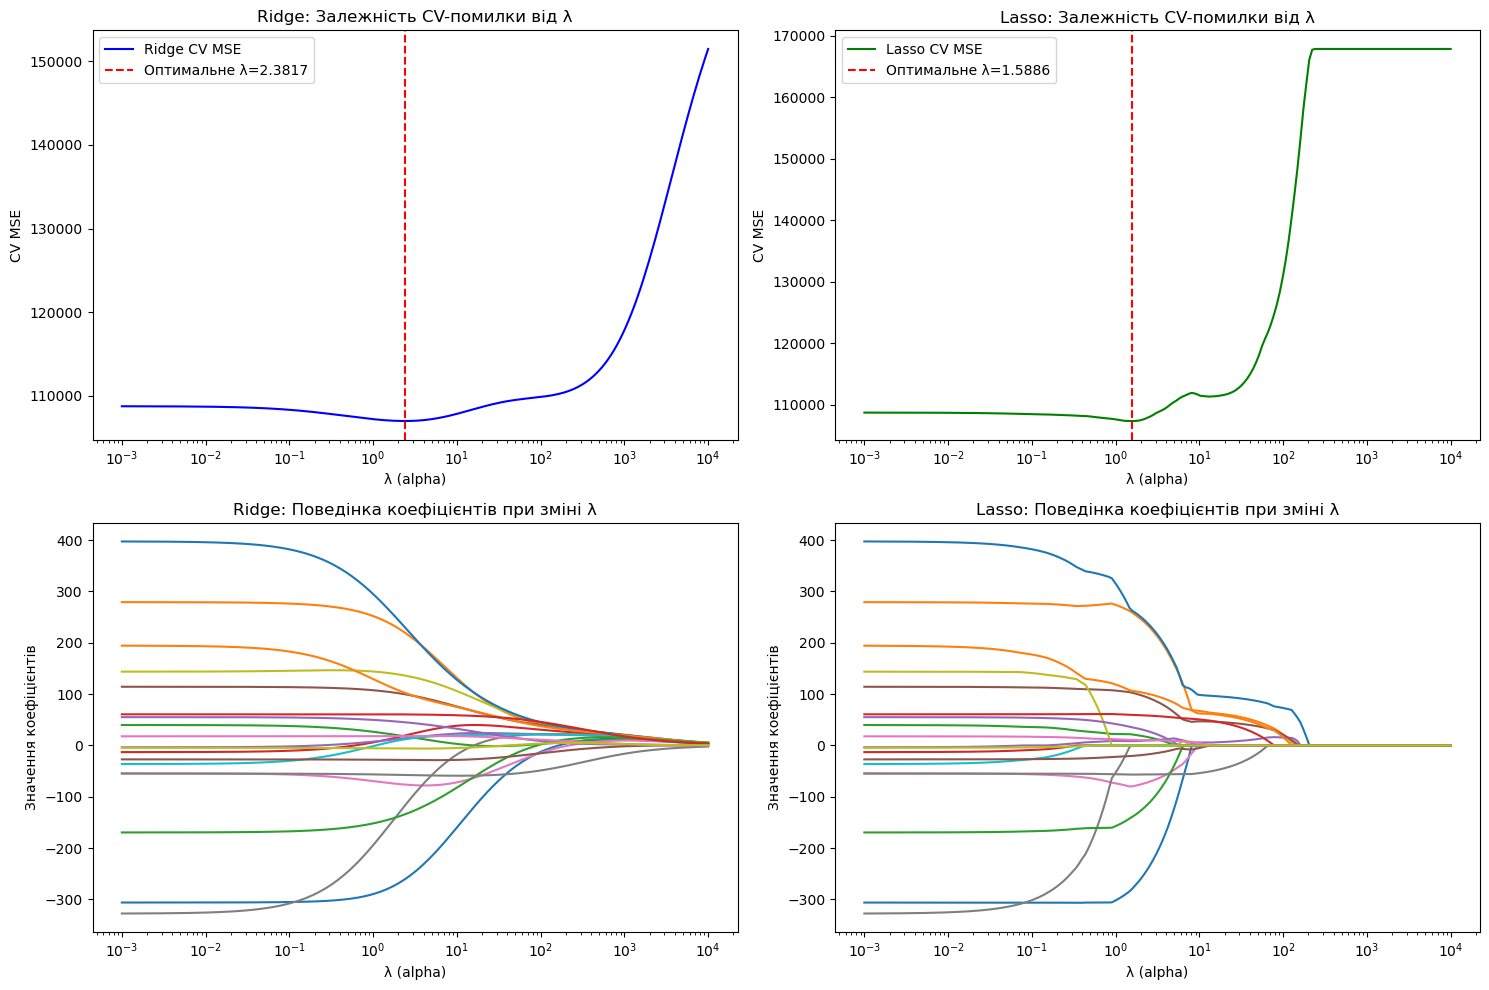

In [17]:
plt.figure(figsize=(15, 10))

# 1. CV-помилка для Ridge
plt.subplot(2, 2, 1)
plt.semilogx(alphas, ridge_cv_errors, label='Ridge CV MSE', color='blue')
plt.axvline(optimal_ridge_alpha, color='r', linestyle='--', label=f'Оптимальне λ={optimal_ridge_alpha:.4f}')
plt.xlabel('λ (alpha)')
plt.ylabel('CV MSE')
plt.title('Ridge: Залежність CV-помилки від λ')
plt.legend()

# 2. CV-помилка для Lasso
plt.subplot(2, 2, 2)
plt.semilogx(alphas, lasso_cv_errors, label='Lasso CV MSE', color='green')
plt.axvline(optimal_lasso_alpha, color='r', linestyle='--', label=f'Оптимальне λ={optimal_lasso_alpha:.4f}')
plt.xlabel('λ (alpha)')
plt.ylabel('CV MSE')
plt.title('Lasso: Залежність CV-помилки від λ')
plt.legend()

# 3. Коефіцієнти Ridge
plt.subplot(2, 2, 3)
plt.semilogx(alphas, ridge_coefs)
plt.xlabel('λ (alpha)')
plt.ylabel('Значення коефіцієнтів')
plt.title('Ridge: Поведінка коефіцієнтів при зміні λ')

# 4. Коефіцієнти Lasso
plt.subplot(2, 2, 4)
plt.semilogx(alphas, lasso_coefs)
plt.xlabel('λ (alpha)')
plt.ylabel('Значення коефіцієнтів')
plt.title('Lasso: Поведінка коефіцієнтів при зміні λ')

plt.tight_layout()
plt.show()

In [18]:
results_table = pd.DataFrame({
    'Модель': ['Лінійна регресія (без рег.)', 'Ridge', 'Lasso'],
    'CV MSE (Помилка)': [lr_cv_mse, min_ridge_error, min_lasso_error],
    'Оптимальне λ': ['-', round(optimal_ridge_alpha, 4), round(optimal_lasso_alpha, 4)],
    'К-сть ненульових коеф.': [X.shape[1], X.shape[1], non_zero_lasso]
})

print("\n Підсумкове порівняння моделей")
print(results_table.to_string(index=False))


 Підсумкове порівняння моделей
                     Модель  CV MSE (Помилка) Оптимальне λ  К-сть ненульових коеф.
Лінійна регресія (без рег.)     108766.427473            -                      19
                      Ridge     106996.740195       2.3817                      19
                      Lasso     107395.254994       1.5886                      14


**Порівняння моделей**
За значенням CV MSE помилки, Ridge регресія має найменшу помилку. Трохи більшу помилку має Lasso, а найбільшу звичайна лінійна регресія без регуляризації.

**Залежність CV-помилки від λ:** Для Ridge спочатку при малих значеннях λ помилка стабільна, далі досягає мінімуму при λ ≈ 2.38, а потім через занадто великий штраф за розмір коефіцієнтів модель починає недонавчатися, і помилка стрімко зростає. Для Lasso мінімальна помилка досягається швидше, при λ = 1.59, але при дуже великих λ модель зануляє всі коефіцієнти, прогнозуючи лише середнє значення зарплати, і помилка стає постійною, утворюючи горизонтальну лінію

**Поведінка коефіцієнтів при зміні λ:** Зі збільшенням параметра штрафу λ коефіцієнти Ridge-регресії плавно та пропорційно стискалися, наближаючись до нуля, але ніколи не обнулялися повністю (усі 19 ознак залишилися в моделі). У моделі Lasso коефіцієнти поводилися інакше: вони різко спадали і по черзі ставали строго рівними нулю.

**Кількість ненульових коефіцієнтів у Lasso:** При оптимальному λ  модель Lasso виконала автоматичний відбір ознак: вона занулила 5 найменш важливих змінних, залишивши лише 14 ненульових коефіцієнтів із початкових 19.

Отже, найбільш стабільною та здатною до узагальнення є Ridge

## Завдання 3. Дерева рішень та глибина

In [19]:
df1 = pd.read_csv(r"C:\Users\User\Documents\Machine_Learning\carseats.csv")
df1.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [21]:
X = df1.drop('Sales', axis=1)
y = df1['Sales']
df1.info()
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


**Побудувати дерева регресії з різною глибиною**

In [22]:
depths = list(range(1, 11)) + [None]
train_mse = []
test_mse = []

for depth in depths:
    tree_reg = DecisionTreeRegressor(max_depth=depth, random_state=123)
    tree_reg.fit(X_train, y_train)

    # прогнози
    y_train_pred = tree_reg.predict(X_train)
    y_test_pred = tree_reg.predict(X_test)

    current_train_mse = mean_squared_error(y_train, y_train_pred)
    current_test_mse = mean_squared_error(y_test, y_test_pred)

    train_mse.append(current_train_mse)
    test_mse.append(current_test_mse)

    depth_label = depth if depth is not None else 'Без обмежень'
    print(f"Глибина: {depth_label:<12} | Train MSE: {current_train_mse:.4f} | Test MSE: {current_test_mse:.4f}")

Глибина: 1            | Train MSE: 5.9497 | Test MSE: 6.1157
Глибина: 2            | Train MSE: 4.6414 | Test MSE: 5.6824
Глибина: 3            | Train MSE: 3.6255 | Test MSE: 6.5664
Глибина: 4            | Train MSE: 2.8265 | Test MSE: 6.8725
Глибина: 5            | Train MSE: 1.9137 | Test MSE: 7.8474
Глибина: 6            | Train MSE: 1.1724 | Test MSE: 7.2156
Глибина: 7            | Train MSE: 0.6684 | Test MSE: 6.9299
Глибина: 8            | Train MSE: 0.3865 | Test MSE: 6.9850
Глибина: 9            | Train MSE: 0.2047 | Test MSE: 6.9488
Глибина: 10           | Train MSE: 0.0958 | Test MSE: 6.6680
Глибина: Без обмежень | Train MSE: 0.0000 | Test MSE: 6.8450


**Побудувати графік**

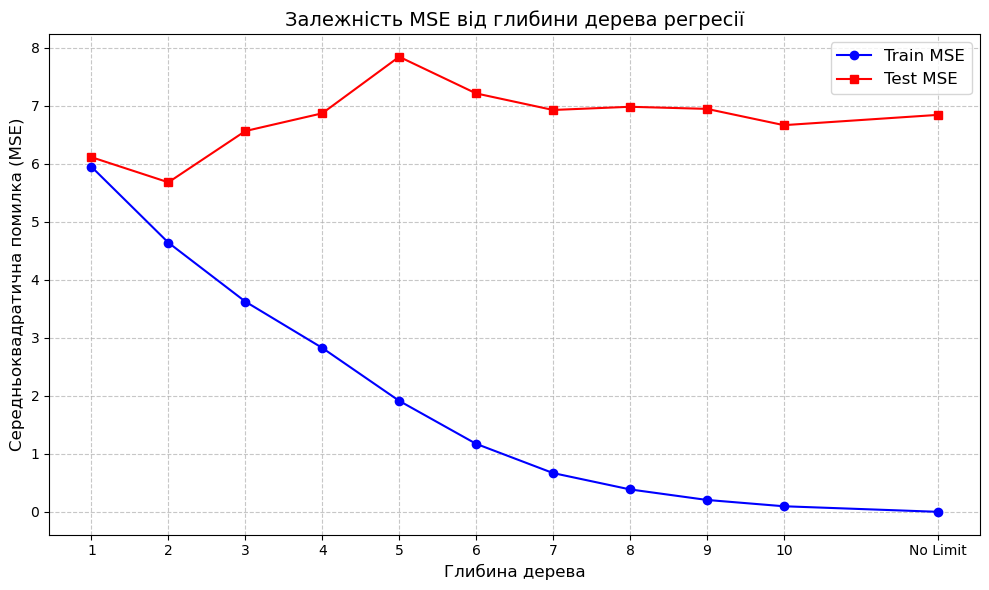

In [23]:
plot_depths = [d if d is not None else 12 for d in depths]
x_labels = [str(d) if d is not None else 'No Limit' for d in depths]

plt.figure(figsize=(10, 6))
plt.plot(plot_depths, train_mse, marker='o', linestyle='-', label='Train MSE', color='blue')
plt.plot(plot_depths, test_mse, marker='s', linestyle='-', label='Test MSE', color='red')

plt.xticks(plot_depths, x_labels)
plt.xlabel('Глибина дерева', fontsize=12)
plt.ylabel('Середньоквадратична помилка (MSE)', fontsize=12)
plt.title('Залежність MSE від глибини дерева регресії', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Можемо бачити, що під час збільшення глибини знижується похибка, але це доходить до перенавчання моделі. Тому найбільш оптимальною кількістю я вважаю глибину 7. Після глибини 7 тестова помилка починає знову зростати, попри те, що тренувальна продовжує падати

## Завдання 4. Вплив обсягу даних на узагальнення

**Оберіть складну модель, Варіюйте обсяг навчальних даних, Повторення експерименту, метрики**

In [24]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
n_repeats = 10
max_depth_complex = 15

mean_mse = []
std_mse = []

for frac in fractions:
    current_mse_scores = []

    n_samples = int(len(X_train) * frac)

    for i in range(n_repeats):
        # Формуємо випадкову підвибірку
        X_sub, y_sub = resample(
            X_train, y_train,
            replace=False,
            n_samples=n_samples,
            random_state=(i * 123)
        )

        model = DecisionTreeRegressor(max_depth=max_depth_complex, random_state=123)
        model.fit(X_sub, y_sub)

        # прогноз
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)

        current_mse_scores.append(mse)

    mean_mse.append(np.mean(current_mse_scores))
    std_mse.append(np.std(current_mse_scores))

    print(f"Обсяг: {frac*100:0.0f}% | Середнє Test MSE: {mean_mse[-1]:.4f} | Std Test MSE: {std_mse[-1]:.4f}")

Обсяг: 20% | Середнє Test MSE: 6.7696 | Std Test MSE: 1.0722
Обсяг: 40% | Середнє Test MSE: 5.9505 | Std Test MSE: 1.0077
Обсяг: 60% | Середнє Test MSE: 5.6872 | Std Test MSE: 1.1751
Обсяг: 80% | Середнє Test MSE: 5.7169 | Std Test MSE: 0.9889
Обсяг: 100% | Середнє Test MSE: 6.8551 | Std Test MSE: 0.0000


**Візуалізація рзультатів**

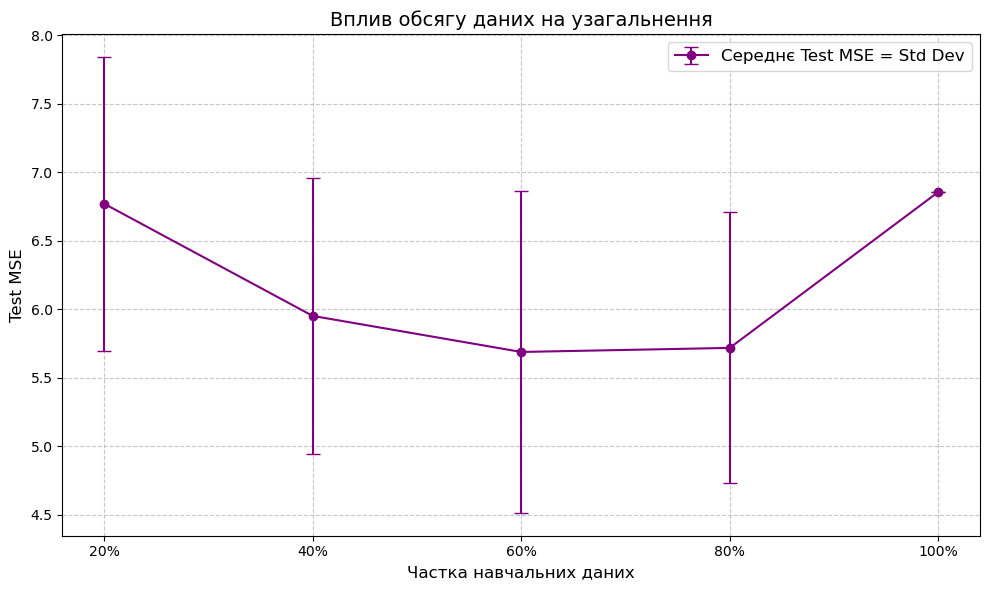

In [25]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    fractions, mean_mse, yerr=std_mse,
    fmt='-o', color='purple', capsize=5, label='Середнє Test MSE = Std Dev'
)

plt.xticks(fractions, ['20%', '40%', '60%', '80%', '100%'])
plt.xlabel('Частка навчальних даних', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('Вплив обсягу даних на узагальнення', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

ксперимент щодо впливу обсягу даних на результати моделювання за допомогою дерева рішень демонструє наступні закономірності:

Дисперсія при малих обсягах: 

1. На малих частках даних (до 40-50%) спостерігається значне стандартне відхилення MSE. Це вказує на високу чутливість глибокого дерева до конкретного складу навчальної вибірки — модель "запам'ятовує" локальні особливості замість глобальних трендів.

2. Стабілізація при 60%: При досягненні певного порогу насичення даних (близько 60%) похибка стабілізується, а її розкид мінімізується, що свідчить про покращення стійкості алгоритму.

3. Ефект перенавчання при 100%: Різке зростання MSE при максимальному обсязі (у певних конфігураціях) може вказувати на те, що дерево занадто глибоко вивчає шум усієї сукупності, втрачаючи здатність до екстраполяції.

Загалом, результати підтверджують, що глибокі непараметричні моделі (як дерева рішень) вимагають значного обсягу даних для адекватної апроксимації цільової функції та мінімізації дисперсії прогнозу.